In [5]:
import numpy as np
import functools
import pickle
import torch
from matplotlib import pyplot as pp

with open('/Users/anshgrover/AIDA3/PINN-tutorial/data/massdamper_data.pkl', 'rb') as f:
    data = pickle.load(f)

data_sampled_random_with_noise = data['data_sampled_random_with_noise']
model_name = 'No external force'
sparsity = 'sparsity 2.0Hz'

t_obs = torch.tensor(data_sampled_random_with_noise[model_name][sparsity]['t'], dtype=torch.float64)
y_obs = torch.tensor(data_sampled_random_with_noise[model_name][sparsity]['x'], dtype=torch.float64)

n = len(t_obs)
p = 1
print(n)

240


In [7]:
m_true      = 2.0
c_true      = 0.3
k_true      = 0.2
delta_true  = c_true / (2 * m_true)
omega0_true = np.sqrt(k_true / m_true)

x0    = [y_obs[0].item(), 0.0]   # first observed state, velocity fixed at 0
sigma = 0.1                       # known noise std
R     = sigma ** 2                # known noise variance

print(f"true delta  = {delta_true:.4f}")
print(f"true omega0 = {omega0_true:.4f}")
print(f"x0          = {x0}")
print(f"R           = {R}")

true delta  = 0.0750
true omega0 = 0.3162
x0          = [0.9644317768389452, 0.0]
R           = 0.010000000000000002


m_sub=16  step_size=0.0313s


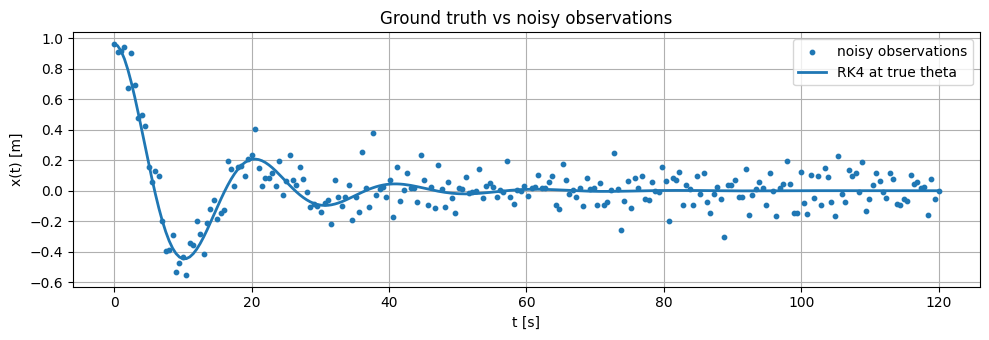

In [8]:
from scipy.integrate import solve_ivp

def msd_scipy(t, y, delta, omega0):
    x, v = y
    return [v, -2*delta*v - omega0**2*x]

K              = 4
h              = (t_obs[1] - t_obs[0]).item()
theorem2_bound = n ** (-5 / (2 * K))
m_sub          = int(np.ceil(h / theorem2_bound))
step_size      = h / m_sub
print(f"m_sub={m_sub}  step_size={step_size:.4f}s")

sol_true = solve_ivp(msd_scipy, (t_obs[0].item(), t_obs[-1].item()), x0,
                     t_eval=t_obs.numpy(), method='RK45', max_step=step_size,
                     args=(delta_true, omega0_true))

x_pred = sol_true.y[0]

pp.figure(figsize=(10, 3.5))
pp.scatter(t_obs, y_obs, s=10, label='noisy observations', zorder=3)
pp.plot(t_obs, x_pred, lw=2, label='RK4 at true theta')
pp.xlabel('t [s]'); pp.ylabel('x(t) [m]')
pp.title('Ground truth vs noisy observations')
pp.legend(); pp.grid(True); pp.tight_layout(); pp.show()

In [9]:
# theta = theta_prior + D @ z,  z ~ N(0, I)
theta_prior = torch.tensor([0.10, 0.35], dtype=torch.float64)
D           = torch.diag(torch.tensor([0.05, 0.10], dtype=torch.float64))

# sanity check: where does true theta sit in z-space?
theta_true_t = torch.tensor([delta_true, omega0_true], dtype=torch.float64)
z_true       = torch.linalg.solve(D, theta_true_t - theta_prior)

print(f"theta_prior = {theta_prior.numpy()}")
print(f"D scales    = {torch.diag(D).numpy()}")
print(f"z_true      = {z_true.numpy()}  (should be O(1))")

theta_prior = [0.1  0.35]
D scales    = [0.05 0.1 ]
z_true      = [-0.5        -0.33772234]  (should be O(1))


In [10]:
def msd(t, y, delta, omega0):
    if not torch.is_tensor(y):
        y = torch.tensor(y, dtype=torch.float64)
    x, v = y[0], y[1]
    return torch.stack([v, -2*delta*v - omega0**2*x])

def rk4_integrate(f, t_eval, y0, m_sub):
    if not torch.is_tensor(y0):
        y0 = torch.tensor(y0, dtype=torch.float64)
    if not torch.is_tensor(t_eval):
        t_eval = torch.tensor(t_eval, dtype=torch.float64)
    Y = [y0]
    y = y0
    for i in range(1, len(t_eval)):
        dt = (t_eval[i] - t_eval[i-1]).item()
        h  = dt / m_sub
        yi = y
        ti = t_eval[i-1].item()
        for _ in range(m_sub):
            k1 = f(ti,       yi            )
            k2 = f(ti + h/2, yi + h/2 * k1)
            k3 = f(ti + h/2, yi + h/2 * k2)
            k4 = f(ti + h,   yi + h   * k3)
            yi = yi + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
            ti += h
        y = yi
        Y.append(y)
    return torch.stack(Y)

In [12]:
theta_prior = torch.tensor([0.10, 0.35], dtype=torch.float64)
D           = torch.diag(torch.tensor([0.05, 0.10], dtype=torch.float64))

def J(z):
    theta  = theta_prior + D @ z
    delta  = theta[0]
    omega0 = theta[1]

    f      = lambda t, y: msd(t, y, delta, omega0)
    Y      = rk4_integrate(f, t_obs, x0, m_sub)
    y_pred = Y[:, 0]

    J_data  = (1.0 / (n * R)) * torch.sum((y_obs - y_pred) ** 2)
    J_prior = 0.5 * torch.dot(z, z)

    return J_data + J_prior

# sanity check
theta_true_t = torch.tensor([delta_true, omega0_true], dtype=torch.float64)
z_true       = torch.linalg.solve(D, theta_true_t - theta_prior)
print(f"z_true    = {z_true.numpy()}")
print(f"J(z_true) = {J(z_true).item():.6f}")
print(f"J_data    = {(1.0/(n*R)*torch.sum((y_obs - torch.tensor(sol_true.y[0], dtype=torch.float64))**2)).item():.6f}")
print(f"J_prior   = {(0.5*torch.dot(z_true,z_true)).item():.6f}")

z_true    = [-0.5        -0.33772234]
J(z_true) = 1.182069
J_data    = 1.000041
J_prior   = 0.182028


In [13]:
z = torch.zeros(2, dtype=torch.float64, requires_grad=True)
optimizer = torch.optim.LBFGS([z], lr=1.0, max_iter=500,
                               tolerance_grad=1e-9, tolerance_change=1e-12)

def closure():
    optimizer.zero_grad()
    loss = J(z)
    loss.backward()
    return loss

optimizer.step(closure)

z_map     = z.detach().clone()
theta_map = (theta_prior + D @ z_map).detach()

print(f"z_MAP       = {z_map.numpy()}")
print(f"theta_MAP   = {theta_map.numpy()}")
print(f"true theta  = [{delta_true:.4f}, {omega0_true:.4f}]")
print(f"J(z_MAP)    = {J(z_map).item():.6f}")

z_MAP       = [-0.11197887 -0.21871647]
theta_MAP   = [0.09440106 0.32812835]
true theta  = [0.0750, 0.3162]
J(z_MAP)    = 1.055280
